# Help the doctor: clinical text to medical specialty

Loading, repair and cleaning follow `specialty_classification.ipynb`. Only `train.csv` is loaded and cleaned here; the official test set is read as-is at the very end (the teachers provide a clean version), and nothing is ever fitted on it.

## 1. Load and structurally repair `train.csv`

The file is semicolon-delimited and has occasional records split across physical lines. Join only the known overflow pattern (a line ending in `";;;` followed by a line that does not start a new known label), then parse each record independently.

In [1]:
import csv
import html
import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

FIG = Path('figures')  # figures for the paper
FIG.mkdir(exist_ok=True)

LABELS = {
    'Surgery', 'Cardiovascular-Pulmonary', 'Orthopedic', 'Radiology',
    'General Medicine', 'Gastroenterology', 'Neurology', 'Obstetrics-Gynecology',
    'Neurosurgery', 'Ophthalmology', 'Psychiatry-Psychology', 'Dermatology',
}
CLASS_ORDER = sorted(LABELS)
ALL_COLS = ['medical_specialty', 'description', 'sample_name', 'transcription', 'keywords']
TEXT_COLS = ALL_COLS[1:]
RECORD_START = re.compile(r'^(' + '|'.join(map(re.escape, LABELS)) + r');')


def load_train(path):
    with open(path, encoding='utf-8-sig', newline='') as source:
        lines = source.read().splitlines()
    records = [line for line in lines[1:] if line.strip()]
    repaired = []
    for line in records:
        continuation = repaired and repaired[-1].endswith('";;;') and not RECORD_START.match(line)
        if continuation:
            head = repaired.pop()[:-4]
            line = head + line.lstrip('"').rstrip('";') + ';'
        repaired.append(line)

    rows, bad_rows = [], []
    for row_number, record in enumerate(repaired):
        fields = next(csv.reader([record], delimiter=';'))
        if any(field.strip() for field in fields[len(ALL_COLS):]):
            bad_rows.append(row_number)
        fields = (fields + [''] * len(ALL_COLS))[:len(ALL_COLS)]
        rows.append([field.replace('""', '"').strip() for field in fields])

    frame = pd.DataFrame(rows, columns=ALL_COLS).replace('', pd.NA)
    if bad_rows:
        raise ValueError(f'Unexpected non-empty extra fields in repaired rows: {bad_rows[:10]}')
    return frame


train_raw = load_train(Path('train.csv'))
print(f'Training rows: {len(train_raw):,}')
print('Training labels recovered:', sorted(train_raw['medical_specialty'].dropna().unique()))
print('Unexpected labels:', sorted(set(train_raw['medical_specialty'].dropna()) - LABELS))

Training rows: 2,669
Training labels recovered: ['Cardiovascular-Pulmonary', 'Dermatology', 'Gastroenterology', 'General Medicine', 'Neurology', 'Neurosurgery', 'Obstetrics-Gynecology', 'Ophthalmology', 'Orthopedic', 'Psychiatry-Psychology', 'Radiology', 'Surgery']
Unexpected labels: []


## 2. Understand the data before modeling

Check record counts, class balance, missingness, field lengths, representative cases, duplicates, and label conflicts. These checks matter because the most common class is much larger than several specialties, and identical reports can carry different labels.

In [2]:
print('Train shape:', train_raw.shape)
print('Duplicate complete training rows:', int(train_raw.duplicated().sum()))
print('\nMissing values (training):')
print(train_raw.isna().sum().to_string())

word_counts = pd.DataFrame({
    column: train_raw[column].fillna('').astype(str).str.split().str.len()
    for column in TEXT_COLS
})
length_summary = pd.DataFrame({
    'missing %': (train_raw[TEXT_COLS].isna().mean() * 100).round(1),
    'median words': word_counts.median().astype(int),
    'mean words': word_counts.mean().round(1),
    'max words': word_counts.max().astype(int),
})
print('\nText-field lengths:')
print(length_summary)

Train shape: (2669, 5)
Duplicate complete training rows: 0

Missing values (training):
medical_specialty      0
description            1
sample_name            7
transcription         31
keywords             450

Text-field lengths:
               missing %  median words  mean words  max words
description          0.0            16        18.9         76
sample_name          0.3             4         3.8          8
transcription        1.2           386       451.7       2454
keywords            16.9            19        22.6        118


                          records  share %
medical_specialty                         
Cardiovascular-Pulmonary      309     11.6
Dermatology                    25      0.9
Gastroenterology              195      7.3
General Medicine              212      7.9
Neurology                     184      6.9
Neurosurgery                   79      3.0
Obstetrics-Gynecology         136      5.1
Ophthalmology                  73      2.7
Orthopedic                    300     11.2
Psychiatry-Psychology          41      1.5
Radiology                     222      8.3
Surgery                       893     33.5

Largest/smallest class ratio: 35.7:1
Always-Surgery accuracy: 33.5%


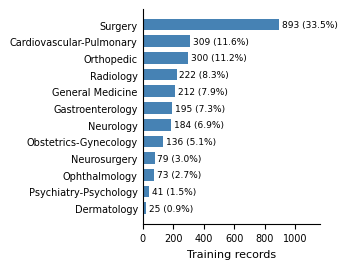

In [3]:
class_counts = train_raw['medical_specialty'].value_counts().reindex(CLASS_ORDER, fill_value=0)
class_summary = pd.DataFrame({
    'records': class_counts,
    'share %': (class_counts / len(train_raw) * 100).round(1),
})
print(class_summary.to_string())
print(f'\nLargest/smallest class ratio: {class_counts.max() / class_counts.min():.1f}:1')
print(f'Always-Surgery accuracy: {class_counts.max() / len(train_raw):.1%}')
# Compact horizontal bar chart sized for one column of a two-column report
sorted_counts = class_counts.sort_values()
fig, ax = plt.subplots(figsize=(3.4, 2.8))
bars = ax.barh(sorted_counts.index, sorted_counts.values, color='steelblue', height=0.7)
ax.bar_label(bars, labels=[f'{n} ({n / len(train_raw):.1%})' for n in sorted_counts.values],
             padding=2, fontsize=6.5)
ax.set_xlabel('Training records', fontsize=8)
ax.tick_params(axis='y', labelsize=7, length=0)
ax.tick_params(axis='x', labelsize=7)
ax.set_xlim(0, sorted_counts.max() * 1.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(FIG / 'class_distribution.pdf', bbox_inches='tight')
plt.show()

In [4]:
print('One example per specialty (text clipped for readability):')
examples = train_raw.groupby('medical_specialty', sort=True).head(1)
for _, row in examples.iterrows():
    print(f"\n[{row['medical_specialty']}] sample={str(row['sample_name'])[:70]!r}")
    print(' description:', str(row['description'])[:180])
    print(' keywords:   ', str(row['keywords'])[:130])

print('\nDuplicate-text conflicts:')
for column in ['description', 'sample_name', 'transcription']:
    subset = train_raw.dropna(subset=[column])
    grouped = subset.groupby(column)['medical_specialty']
    label_counts = grouped.nunique()
    conflicting = label_counts[label_counts > 1].index
    affected = int(grouped.size().reindex(conflicting).sum()) if len(conflicting) else 0
    print(f'{column}: {len(conflicting):,} repeated text values have multiple labels; {affected:,} rows affected')

One example per specialty (text clipped for readability):

[Cardiovascular-Pulmonary] sample='Chest Pain - Cardiac Consult'
 description: Chest pain, possible syncopal spells.  She has been having multiple cardiovascular complaints including chest pains, which feel like cramps and sometimes like a dull ache, which wi
 keywords:    cardiovascular / pulmonary, chest pain, syncopal, echocardiogram, ekg, cardiac etiology, syncopal spells, rhythm, flexeril, cardia

[Gastroenterology] sample='Melena - ICU Followup'
 description: Reason for ICU followup today is acute anemia secondary to upper GI bleeding with melena with dropping hemoglobin from 11 to 8, status post transfusion of 2 units PRBCs with EGD pe
 keywords:    gastroenterology, anemia, gi bleeding, hemoglobin, ulcerative, esophagitis, obstructive pulmonary disease, icu followup, infection

[Psychiatry-Psychology] sample='Neuropsychological Evaluation - 5'
 description: The patient comes in for a neurology consultation regarding her

## 3. Audit the keyword field for target leakage

Check whether a keyword list begins with an exact specialty name (including `obstetrics / gynecology`). This directly encodes the answer, so the marker is removed from the text in the cleaning step and the models never see it.

In [5]:
LABEL_FROM_PREFIX = {label.lower(): label for label in LABELS}
LABEL_FROM_PREFIX.update({label.lower().replace('-', ' / '): label for label in LABELS})


def label_marker(row):
    # Some malformed rows have the keyword list shifted into description or transcription.
    for column in ['keywords', 'description', 'transcription']:
        value = row[column]
        if pd.notna(value):
            first_term = str(value).split(',', 1)[0].strip().lower()
            if first_term in LABEL_FROM_PREFIX:
                return LABEL_FROM_PREFIX[first_term]
    return None


train_marker = train_raw.apply(label_marker, axis=1)
marker_rows = train_marker.notna()
marker_matches = int((train_marker[marker_rows] == train_raw.loc[marker_rows, 'medical_specialty']).sum())
marker_mismatches = int(marker_rows.sum()) - marker_matches
print(f'Train rows with exact specialty marker: {int(marker_rows.sum()):,}/{len(train_raw):,} ({marker_rows.mean():.1%})')
print(f'Markers matching their training labels: {marker_matches:,}; mismatches: {marker_mismatches:,}')

Train rows with exact specialty marker: 2,219/2,669 (83.1%)
Markers matching their training labels: 2,219; mismatches: 0


## 4. Clean and normalize the text

Normalize Unicode and HTML entities, collapse whitespace, remove an exact leading specialty marker from any text field, and cut the appended `NOTE` disclaimer from keywords. Preserve clinically meaningful words, abbreviations, numbers, and punctuation rather than aggressively stripping medical terminology. Fields that end up empty stay missing.

In [6]:
PREFIX_PATTERN = re.compile(
    r'^\s*(?:' + '|'.join(re.escape(value) for value in sorted(LABEL_FROM_PREFIX, key=len, reverse=True)) + r')\s*,\s*',
    flags=re.IGNORECASE,
)
DISCLAIMER_PATTERN = re.compile(r'NOTE\b.*$', flags=re.IGNORECASE | re.DOTALL)


def clean_text(value, column):
    if pd.isna(value):
        return ''
    text = unicodedata.normalize('NFKC', html.unescape(str(value)))
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = PREFIX_PATTERN.sub('', text)
    if column == 'keywords':
        text = DISCLAIMER_PATTERN.sub('', text)
    return re.sub(r'\s+', ' ', text).strip(' ,')


def clean_frame(frame):
    cleaned = frame.copy()
    for column in TEXT_COLS:
        cleaned[column] = cleaned[column].map(lambda value: clean_text(value, column))
    return cleaned.replace('', pd.NA)


train_clean = clean_frame(train_raw)
print('Clean train shape:', train_clean.shape)
print('Records with no text at all:', int(train_clean[TEXT_COLS].isna().all(axis=1).sum()))
print('Marker text remaining in cleaned keywords:', int(train_clean['keywords'].fillna('').str.match(PREFIX_PATTERN).sum()))

Clean train shape: (2669, 5)
Records with no text at all: 0
Marker text remaining in cleaned keywords: 0


## 5. Experimental setup: our own held-out set

The official test set has no labels, so 20% of `train.csv` is kept aside as a held-out set; the rest (dev) is used for all training and model selection. The split uses `StratifiedGroupKFold` (random state 42): stratified so that every specialty keeps roughly the same share on both sides, and grouped by transcription (description when the transcription is missing) so that copies of the same report never end up on both sides. Otherwise the model could recognise a held-out text it has already seen in training, which would make the scores optimistic.

In [7]:
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

data = train_clean.reset_index(drop=True)

# Copies of the same report go to the same side of the split, so the held-out
# set only has texts the model has never seen
groups = data["transcription"].fillna(data["description"])

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
dev_idx, holdout_idx = next(splitter.split(data, data["medical_specialty"], groups))
dev, holdout = data.iloc[dev_idx], data.iloc[holdout_idx]

print("dev:", len(dev), " held-out:", len(holdout),
      " held-out texts also in dev:", groups[holdout_idx].isin(groups[dev_idx]).sum())
print(pd.DataFrame({
    "dev %": (dev["medical_specialty"].value_counts(normalize=True) * 100).round(1),
    "held-out %": (holdout["medical_specialty"].value_counts(normalize=True) * 100).round(1),
}))

dev: 2129  held-out: 540  held-out texts also in dev: 0
                          dev %  held-out %
medical_specialty                          
Cardiovascular-Pulmonary   12.1         9.6
Dermatology                 1.0         0.6
Gastroenterology            7.5         6.7
General Medicine            8.3         6.5
Neurology                   6.5         8.3
Neurosurgery                2.8         3.5
Obstetrics-Gynecology       4.5         7.4
Ophthalmology               2.8         2.6
Orthopedic                 11.4        10.7
Psychiatry-Psychology       1.6         1.5
Radiology                   8.0         9.4
Surgery                    33.5        33.1


### Evaluation metrics

`evaluate` prints, for one set of predictions:

- **accuracy**: share of records predicted correctly;
- **macro precision**: for each class, the share of records predicted as that class that really belong to it, averaged over the 12 classes;
- **macro recall**: for each class, the share of its records that the model finds, averaged over the 12 classes;
- **macro-F1**: the per-class F1 (harmonic mean of precision and recall), averaged over the 12 classes;
- **worst class F1**: the lowest per-class F1.

Macro averages give every specialty the same weight, so a model cannot score well by only getting Surgery right. PASS means both grading thresholds are met: accuracy above 49% and every class F1 at least 25%. It returns the per-class F1, which the result tables below are built from.

In [8]:
from sklearn.metrics import precision_recall_fscore_support

CLASSES = sorted(LABELS)


def evaluate(name, y_true, y_pred, show_per_class=False):
    """Print the scores used for grading and return the per-class F1.

    Precision and recall are macro-averaged (every class counts the same). With
    show_per_class=True the per-class precision, recall, F1 and support are printed too.
    """
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASSES, zero_division=0)
    per_class = pd.Series(f1, index=CLASSES)
    acc = accuracy_score(y_true, y_pred)
    passed = acc > 0.49 and per_class.min() >= 0.25  # grading thresholds
    print(f"{name:35s} accuracy {acc:.3f}  macro-P {precision.mean():.3f}  macro-R {recall.mean():.3f}  "
          f"macro-F1 {per_class.mean():.3f}  worst class F1 {per_class.min():.3f}  {'PASS' if passed else 'FAIL'}")
    if show_per_class:
        print(pd.DataFrame({"precision": precision, "recall": recall, "F1": f1, "support": support},
                           index=CLASSES).round(3).sort_values("F1"))
    return per_class

## 6. Baseline from the project description

TF-IDF on `description` only, with lowercasing and Porter stemming (e.g. "fractures" becomes "fractur"), followed by a Multinomial Naive Bayes classifier. Trained on dev, scored on the held-out set. Every later model has to beat this.

In [9]:
stemmer = PorterStemmer()
tokenize = TfidfVectorizer().build_analyzer()  # lowercases and splits into words


def stemmed_words(text):
    return [stemmer.stem(word) for word in tokenize(text)]


baseline = make_pipeline(TfidfVectorizer(analyzer=stemmed_words), MultinomialNB())
baseline.fit(dev["description"].fillna(""), dev["medical_specialty"])
baseline_pred = baseline.predict(holdout["description"].fillna(""))

baseline_f1 = evaluate("baseline: NB + TF-IDF (description)", holdout["medical_specialty"], baseline_pred)
print(baseline_f1.round(2).sort_values())

baseline: NB + TF-IDF (description) accuracy 0.409  macro-P 0.228  macro-R 0.167  macro-F1 0.163  worst class F1 0.000  FAIL
Dermatology                 0.00
Gastroenterology            0.00
Neurosurgery                0.00
Obstetrics-Gynecology       0.00
Ophthalmology               0.00
Psychiatry-Psychology       0.00
Neurology                   0.04
Orthopedic                  0.22
Radiology                   0.25
Cardiovascular-Pulmonary    0.35
General Medicine            0.54
Surgery                     0.56
dtype: float64


## 7. All four fields with linear classifiers

The baseline sees only the short description. Here the four text fields are joined into one document per record, so the models can also use the transcription, sample name and keywords.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


def combine_fields(df):
    """Join the four text fields into one string; missing fields become empty."""
    return df[TEXT_COLS].fillna("").agg(" ".join, axis=1)


X_dev, y_dev = combine_fields(dev), dev["medical_specialty"]
X_holdout, y_holdout = combine_fields(holdout), holdout["medical_specialty"]
print(X_dev.iloc[0][:300])

Chest pain, possible syncopal spells. She has been having multiple cardiovascular complaints including chest pains, which feel like cramps and sometimes like a dull ache, which will last all day long. Chest Pain - Cardiac Consult REASON FOR REFERRAL: Chest pain, possible syncopal spells.,She is a ve


Three classifiers on the joined text: Naive Bayes with the baseline's stemmed TF-IDF, and Logistic Regression and a linear SVM with TF-IDF (sublinear term frequency, words seen in at least 2 records). `class_weight="balanced"` makes errors on small classes cost more, which counters the imbalance. Each model is trained on dev and scored on the held-out set.

In [11]:
models = {
    "NB + TF-IDF (all fields)": make_pipeline(
        TfidfVectorizer(analyzer=stemmed_words),
        MultinomialNB()),
    "LogReg + TF-IDF (all fields)": make_pipeline(
        TfidfVectorizer(sublinear_tf=True, min_df=2),
        LogisticRegression(class_weight="balanced", max_iter=2000)),
    "LinearSVC + TF-IDF (all fields)": make_pipeline(
        TfidfVectorizer(sublinear_tf=True, min_df=2),
        LinearSVC(class_weight="balanced")),
}

per_class_f1 = {"baseline": baseline_f1}

for name, model in models.items():
    model.fit(X_dev, y_dev)
    per_class_f1[name] = evaluate(name, y_holdout, model.predict(X_holdout))

NB + TF-IDF (all fields)            accuracy 0.413  macro-P 0.207  macro-R 0.172  macro-F1 0.148  worst class F1 0.000  FAIL
LogReg + TF-IDF (all fields)        accuracy 0.567  macro-P 0.603  macro-R 0.729  macro-F1 0.638  worst class F1 0.475  PASS
LinearSVC + TF-IDF (all fields)     accuracy 0.581  macro-P 0.611  macro-R 0.725  macro-F1 0.648  worst class F1 0.505  PASS


Per-class F1 of the baseline and the three models, next to the number of held-out records of each class, sorted from the smallest class. The small classes are where the models differ most.

In [12]:
results = pd.DataFrame(per_class_f1).round(2)
results["held-out size"] = y_holdout.value_counts()
results.sort_values("held-out size")

,baseline,NB + TF-IDF (all fields),LogReg + TF-IDF (all fields),LinearSVC + TF-IDF (all fields),held-out size
Dermatology,0.00,0.00,0.86,0.86,3
Psychiatry-Psychology,0.00,0.00,0.88,0.88,8
Ophthalmology,0.00,0.00,0.81,0.81,14
Neurosurgery,0.00,0.00,0.52,0.52,19
General Medicine,0.54,0.56,0.73,0.74,35
Gastroenterology,0.00,0.00,0.60,0.62,36
Obstetrics-Gynecology,0.00,0.00,0.61,0.62,40
Neurology,0.04,0.19,0.58,0.57,45
Radiology,0.25,0.00,0.53,0.51,51
Cardiovascular-Pulmonary,0.35,0.37,0.57,0.62,52


## 8. Data augmentation

The classes are strongly imbalanced, so three ways of adding training data are defined:

- **oversample**: copy records of the smaller classes until every class is as large as the largest one;
- **EDA copies** (Wei & Zou, 2019): the same, but each copy is perturbed by replacing about 10% of the words in `description` and `transcription` with a WordNet synonym and deleting about 10% of them, so the copies are not exact duplicates;
- **field dropout**: add one copy of the data without keywords and one without transcription, so the model also learns to work when a field is missing.

Only the training part is ever augmented; validation folds and the held-out set stay untouched.

In [13]:
import random

import nltk
from nltk.corpus import wordnet

nltk.download("wordnet", quiet=True)


def synonym(word, rng):
    lemmas = {lemma.name().replace("_", " ") for synset in wordnet.synsets(word.lower()) for lemma in synset.lemmas()}
    lemmas.discard(word.lower())
    return rng.choice(sorted(lemmas)) if lemmas else word


def eda_perturb(text, rng, p=0.1):
    """EDA (Wei & Zou, 2019): swap ~p of the words for a WordNet synonym, then delete ~p of them.
    Random swap is left out because word order doesn't matter for TF-IDF."""
    if pd.isna(text):
        return text
    words = [synonym(w, rng) if rng.random() < p else w for w in text.split()]
    kept = [w for w in words if rng.random() >= p]
    return " ".join(kept or words)


def oversample(df, perturb=False, seed=0):
    """Add copies of the smaller classes until every class is as big as the largest one.
    With perturb=True the copies are EDA-perturbed instead of exact duplicates."""
    rng = random.Random(seed)
    target = df["medical_specialty"].value_counts().max()
    extra = []
    for label, rows in df.groupby("medical_specialty"):
        copies = rows.sample(target - len(rows), replace=True, random_state=seed)
        if perturb:
            for col in ["description", "transcription"]:
                copies[col] = copies[col].map(lambda text: eda_perturb(text, rng))
        extra.append(copies)
    return pd.concat([df, *extra])


def field_dropout(df):
    """Add one copy without keywords and one without transcription: these fields are
    missing more often in the test set (20% and 3%) than in train."""
    return pd.concat([df, df.assign(keywords=pd.NA), df.assign(transcription=pd.NA)])


example = holdout["description"].iloc[3]
print("original: ", example)
print("perturbed:", eda_perturb(example, random.Random(1), p=0.2))

original:  Delayed primary chest closure. Open chest status post modified stage 1 Norwood operation. The patient is a newborn with diagnosis of hypoplastic left heart syndrome who 48 hours prior to the current procedure has undergone a modified stage 1 Norwood operation.
perturbed: check primary chest closure. chest condition post modified stage 1 Norwood operation. The patient equal A newborn with of heart syndrome who 48 hours prior to the current has modified stage ane Norwood operation.


`cross_validate` runs 5-fold grouped cross-validation on dev (folds made the same way as the held-out split, random state 0). For each fold the model is trained on the other four folds, augmented if requested, and scored on the untouched validation fold. It returns the mean accuracy, macro-F1 and worst class F1 over the folds, plus the standard deviation of macro-F1, which shows how much a score moves just from the choice of fold.

In [14]:
dev_groups = groups[dev_idx]
cv_folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
                .split(dev, dev["medical_specialty"], dev_groups))


def cross_validate(make_model, augment=None, train_folds=None):
    """5-fold grouped CV on dev. The training folds are augmented with `augment`, or passed in
    already augmented as `train_folds`. Validation folds are never augmented."""
    if train_folds is None:
        train_folds = [dev.iloc[train_idx] for train_idx, _ in cv_folds]
        if augment is not None:
            train_folds = [augment(fold) for fold in train_folds]

    scores = []
    for (_, val_idx), fold_train in zip(cv_folds, train_folds):
        fold_val = dev.iloc[val_idx]
        model = make_model().fit(combine_fields(fold_train), fold_train["medical_specialty"])
        pred = model.predict(combine_fields(fold_val))
        per_class = f1_score(fold_val["medical_specialty"], pred, labels=CLASSES, average=None, zero_division=0)
        scores.append({
            "accuracy": accuracy_score(fold_val["medical_specialty"], pred),
            "macro-F1": per_class.mean(),
            "worst class F1": per_class.min(),
        })
    scores = pd.DataFrame(scores)
    return {**scores.mean().round(3), "macro-F1 std": round(scores["macro-F1"].std(), 3)}

A first experiment with Logistic Regression: does handling the imbalance help, and which way works best? No weighting, class weighting, plain oversampling, EDA oversampling, and class weighting combined with field dropout.

In [15]:
def logreg(class_weight=None):
    return make_pipeline(TfidfVectorizer(sublinear_tf=True, min_df=2),
                         LogisticRegression(class_weight=class_weight, max_iter=2000))


experiments = {
    "no weighting, no augmentation": (logreg, None),
    "class_weight='balanced'": (lambda: logreg("balanced"), None),
    "oversampling: duplicates": (logreg, oversample),
    "oversampling: EDA copies": (logreg, lambda df: oversample(df, perturb=True)),
    "balanced + field dropout": (lambda: logreg("balanced"), field_dropout),
}

cv_results = pd.DataFrame({name: cross_validate(make, augment) for name, (make, augment) in experiments.items()}).T
cv_results

,accuracy,macro-F1,worst class F1,macro-F1 std
"no weighting, no augmentation",0.553,0.358,0.000,0.044
class_weight='balanced',0.563,0.597,0.410,0.035
oversampling: duplicates,0.573,0.592,0.336,0.048
oversampling: EDA copies,0.579,0.596,0.387,0.037
balanced + field dropout,0.578,0.606,0.399,0.031


## 9. Model comparison: every model with and without augmentation

Six classifiers are defined, each on top of word TF-IDF: Logistic Regression, Linear SVM, Linear SVM with extra character 3-5-grams, Ridge, Complement NB and kNN with cosine distance. Every model is combined with every augmentation and scored with the same 5-fold grouped cross-validation on dev.

In [16]:
from sklearn.linear_model import RidgeClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_union


def word_tfidf(**kwargs):
    return TfidfVectorizer(sublinear_tf=True, min_df=2, **kwargs)


def char_tfidf():
    # character 3-5-grams inside words: robust to typos and picks up word parts like "-ectomy" or "cardio-"
    return TfidfVectorizer(sublinear_tf=True, min_df=2, analyzer="char_wb", ngram_range=(3, 5), max_features=50000)


candidates = {
    "Logistic Regression": lambda: make_pipeline(
        word_tfidf(), LogisticRegression(class_weight="balanced", max_iter=2000)),
    "Linear SVM": lambda: make_pipeline(
        word_tfidf(), LinearSVC(class_weight="balanced")),
    "Linear SVM (word + char)": lambda: make_pipeline(
        make_union(word_tfidf(), char_tfidf()), LinearSVC(class_weight="balanced")),
    "Ridge": lambda: make_pipeline(
        word_tfidf(), RidgeClassifier(class_weight="balanced")),
    "Complement NB": lambda: make_pipeline(
        word_tfidf(), ComplementNB()),
    "kNN (cosine)": lambda: make_pipeline(
        word_tfidf(), KNeighborsClassifier(n_neighbors=10, metric="cosine", weights="distance")),
}

Each augmentation is applied once to every training fold, and the same augmented folds are reused for all six models. This keeps the comparison fair and avoids recomputing EDA, which is slow.

In [17]:
augmentations = {
    "none": None,
    "oversample": oversample,
    "EDA": lambda df: oversample(df, perturb=True),
    "field dropout": field_dropout,
}

# Augment every training fold once and reuse it for all models (EDA is slow)
augmented_folds = {
    name: [augment(dev.iloc[train_idx]) if augment else dev.iloc[train_idx] for train_idx, _ in cv_folds]
    for name, augment in augmentations.items()
}
for name, folds in augmented_folds.items():
    print(f"{name:14s} rows in first training fold: {len(folds[0])}")

none           rows in first training fold: 1707
oversample     rows in first training fold: 6876
EDA            rows in first training fold: 6876
field dropout  rows in first training fold: 5121


The 24 runs (6 models × 4 augmentations, 5 folds each) are spread over all CPU cores but two, so the computer stays usable. This is the slowest cell of the notebook.

In [18]:
import os
import time

from joblib import Parallel, delayed, parallel_config


def run_one(model_name, make_model, aug_name, train_folds):
    start = time.time()
    scores = cross_validate(make_model, train_folds=train_folds)
    return {"model": model_name, "augmentation": aug_name, **scores}, time.time() - start


# One job per (model, augmentation) pair, spread over all CPU cores except 2, so the computer stays usable.
# inner_max_num_threads=1 stops BLAS from spawning extra threads inside each worker.
N_JOBS = max(1, (os.cpu_count() or 4) - 2)
jobs = [(model_name, make_model, aug_name, train_folds)
        for model_name, make_model in candidates.items()
        for aug_name, train_folds in augmented_folds.items()]
with parallel_config(backend="loky", inner_max_num_threads=1):
    results = Parallel(n_jobs=N_JOBS, verbose=5)(delayed(run_one)(*job) for job in jobs)

rows = []
for row, seconds in results:
    rows.append(row)
    print(f"{row['model']:26s} {row['augmentation']:14s} macro-F1 {row['macro-F1']:.3f}  ({seconds:.0f}s)")

comparison = pd.DataFrame(rows)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    5.8s
[Parallel(n_jobs=8)]: Done  14 out of  24 | elapsed:   29.3s remaining:   21.0s
[Parallel(n_jobs=8)]: Done  19 out of  24 | elapsed:   36.5s remaining:    9.6s


Logistic Regression        none           macro-F1 0.597  (4s)
Logistic Regression        oversample     macro-F1 0.592  (16s)
Logistic Regression        EDA            macro-F1 0.596  (18s)
Logistic Regression        field dropout  macro-F1 0.606  (10s)
Linear SVM                 none           macro-F1 0.618  (3s)
Linear SVM                 oversample     macro-F1 0.614  (14s)
Linear SVM                 EDA            macro-F1 0.603  (11s)
Linear SVM                 field dropout  macro-F1 0.620  (7s)
Linear SVM (word + char)   none           macro-F1 0.612  (52s)
Linear SVM (word + char)   oversample     macro-F1 0.610  (186s)
Linear SVM (word + char)   EDA            macro-F1 0.595  (138s)
Linear SVM (word + char)   field dropout  macro-F1 0.614  (98s)
Ridge                      none           macro-F1 0.618  (3s)
Ridge                      oversample     macro-F1 0.614  (13s)
Ridge                      EDA            macro-F1 0.615  (13s)
Ridge                      field dropout  

[Parallel(n_jobs=8)]: Done  24 out of  24 | elapsed:  3.2min finished


The results as three tables (macro-F1, accuracy, worst class F1): one row per model, one column per augmentation, sorted by the score without augmentation.

In [19]:
for metric in ["macro-F1", "accuracy", "worst class F1"]:
    table = comparison.pivot(index="model", columns="augmentation", values=metric)[list(augmentations)]
    print(f"\n{metric}")
    print(table.sort_values("none", ascending=False))


macro-F1
augmentation               none  oversample    EDA  field dropout
model                                                            
Linear SVM                0.618       0.614  0.603          0.620
Ridge                     0.618       0.614  0.615          0.620
Linear SVM (word + char)  0.612       0.610  0.595          0.614
Logistic Regression       0.597       0.592  0.596          0.606
kNN (cosine)              0.527       0.541  0.547          0.535
Complement NB             0.367       0.527  0.533          0.412

accuracy
augmentation               none  oversample    EDA  field dropout
model                                                            
Linear SVM (word + char)  0.591       0.585  0.589          0.595
Linear SVM                0.589       0.583  0.589          0.594
Ridge                     0.576       0.580  0.587          0.583
kNN (cosine)              0.576       0.517  0.529          0.570
Logistic Regression       0.563       0.573  0.579      

## 10. The three finalists

Three (model, augmentation) pairs are picked from the cross-validation tables above, each with a different model. The table shows their cross-validation scores side by side, including the macro-F1 standard deviation, to judge whether the differences between them are larger than the fold-to-fold noise.

In [20]:
finalists = {
    "Ridge + oversample": ("Ridge", "oversample"),
    "Linear SVM + field dropout": ("Linear SVM", "field dropout"),
    "Linear SVM (word + char) + oversample": ("Linear SVM (word + char)", "oversample"),
}

# Is the gap between the finalists bigger than the fold-to-fold noise?
cv_table = comparison.set_index(["model", "augmentation"]).loc[list(finalists.values())]
cv_table.index = list(finalists)
cv_table

,accuracy,macro-F1,worst class F1,macro-F1 std
Ridge + oversample,0.580,0.614,0.414,0.025
Linear SVM + field dropout,0.594,0.620,0.433,0.025
Linear SVM (word + char) + oversample,0.585,0.610,0.427,0.027


## 11. Final check on the held-out set

Each finalist is trained on all of dev (augmented as in its pair), then scored once on the held-out records it has never seen. The table lists the per-class F1 of each finalist next to the number of held-out records of that class.

In [21]:
def fit_augmented(make_model, train, aug_name):
    augment = augmentations[aug_name]
    train = augment(train) if augment else train
    return make_model().fit(combine_fields(train), train["medical_specialty"])


# Only three fits, so they run one after another (no joblib, no pickling problems)
holdout_preds, finalist_f1 = {}, {}
for name, (model_name, aug_name) in finalists.items():
    start = time.time()
    holdout_preds[name] = fit_augmented(candidates[model_name], dev, aug_name).predict(X_holdout)
    finalist_f1[name] = evaluate(f"{name} ({time.time() - start:.0f}s)", y_holdout, holdout_preds[name])

finalist_results = pd.DataFrame(finalist_f1).round(2)
finalist_results["held-out size"] = y_holdout.value_counts()
finalist_results.sort_values("held-out size")

Ridge + oversample (3s)             accuracy 0.583  macro-P 0.614  macro-R 0.742  macro-F1 0.651  worst class F1 0.472  PASS
Linear SVM + field dropout (1s)     accuracy 0.585  macro-P 0.614  macro-R 0.726  macro-F1 0.650  worst class F1 0.484  PASS
Linear SVM (word + char) + oversample (44s) accuracy 0.585  macro-P 0.612  macro-R 0.722  macro-F1 0.649  worst class F1 0.467  PASS


,Ridge + oversample,Linear SVM + field dropout,Linear SVM (word + char) + oversample,held-out size
Dermatology,0.86,0.86,0.86,3
Psychiatry-Psychology,0.88,0.88,0.88,8
Ophthalmology,0.82,0.81,0.81,14
Neurosurgery,0.51,0.52,0.50,19
General Medicine,0.77,0.74,0.77,35
Gastroenterology,0.65,0.63,0.63,36
Obstetrics-Gynecology,0.62,0.63,0.64,40
Neurology,0.58,0.59,0.57,45
Radiology,0.47,0.48,0.47,51
Cardiovascular-Pulmonary,0.65,0.62,0.63,52


## 12. Error analysis of the chosen model

The chosen model's per-class precision, recall and F1 on the held-out set, the specialty pairs it confuses most often, and a few misclassified records to read the text behind the numbers.

In [22]:
# On held-out the three finalists tie on macro-F1 (0.651 / 0.650 / 0.649), well within the CV std.
# Worst-class F1 on held-out: 0.472 / 0.484 / 0.467; all three clear the grading rule "no class below 0.25".
best = "Ridge + oversample"
print("final model:", best)
evaluate(best, y_holdout, holdout_preds[best], show_per_class=True)

errors = pd.DataFrame({"true": y_holdout.values, "predicted": holdout_preds[best]}, index=y_holdout.index)
errors = errors[errors["true"] != errors["predicted"]]
print(f"\n{len(errors)} errors out of {len(y_holdout)}; most frequent confusions:")
print(errors.value_counts().head(10))

# A few misclassified records, to read the text behind the numbers
print()
print(holdout.loc[errors.index[:5], ["medical_specialty", "description"]]
      .assign(predicted=errors["predicted"].iloc[:5]).to_string())

final model: Ridge + oversample
Ridge + oversample                  accuracy 0.583  macro-P 0.614  macro-R 0.742  macro-F1 0.651  worst class F1 0.472  PASS
                          precision  recall     F1  support
Radiology                     0.553   0.412  0.472       51
Surgery                       0.747   0.363  0.489      179
Neurosurgery                  0.354   0.895  0.507       19
Orthopedic                    0.517   0.517  0.517       58
Neurology                     0.562   0.600  0.581       45
Obstetrics-Gynecology         0.536   0.750  0.625       40
Cardiovascular-Pulmonary      0.563   0.769  0.650       52
Gastroenterology              0.536   0.833  0.652       36
General Medicine              0.674   0.886  0.765       35
Ophthalmology                 0.700   1.000  0.824       14
Dermatology                   0.750   1.000  0.857        3
Psychiatry-Psychology         0.875   0.875  0.875        8

225 errors out of 540; most frequent confusions:
true         

## 13. Final model and `results.txt`

The chosen model is retrained on all labelled data (dev + held-out, augmented the same way) and predicts one specialty per record of the official test set. The test file is read as-is: no repair or cleaning is applied to it. Set `TEST_PATH` to the clean test file from the teachers. The final check makes sure there is exactly one prediction per test record before `results.txt` is written (no header, one label per line, same order as the test file).

In [23]:
TEST_PATH = Path('test_no_labels.csv')  # point this at the clean test file from the teachers

test = pd.read_csv(TEST_PATH, sep=';', header=None, names=TEXT_COLS, encoding='utf-8-sig')
if [str(value).strip().lower() for value in test.iloc[0]] == TEXT_COLS:
    test = test.iloc[1:].reset_index(drop=True)  # the file came with a header row
print('test:', test.shape)

model_name, aug_name = finalists[best]
final_model = fit_augmented(candidates[model_name], data, aug_name)
test_pred = final_model.predict(combine_fields(test))

assert len(test_pred) == len(test), 'one prediction per test record'
with open('results1.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(test_pred) + '\n')

print(f'{best}: wrote {len(test_pred)} predictions to results.txt')
print(pd.Series(test_pred).value_counts())

test: (409, 4)
Ridge + oversample: wrote 409 predictions to results.txt
Surgery                     91
Orthopedic                  51
Cardiovascular-Pulmonary    48
Gastroenterology            38
Neurology                   33
Obstetrics-Gynecology       32
General Medicine            32
Neurosurgery                26
Radiology                   25
Ophthalmology               20
Psychiatry-Psychology       11
Dermatology                  2
Name: count, dtype: int64
